# MIN3P reactive-transport sweep — calcite dissolution (`dissol`)

This notebook reads and displays the results of a MIN3P sweep run through Omphalos (`min3p` backend) with `dissol_sweep.yaml`.

**Problem** (`reactran/dissol`): a 1-D column (z = 0 → 0.4 m) initially bearing a small amount of calcite in near-equilibrium water. Acidic, carbonate-rich water is injected at the inflow boundary (z = 0) and drives a calcite **dissolution front** over 6 days.

**Sweep**: the inflow acidity — the free H⁺ concentration imposed at the inflow boundary — over four increasingly aggressive waters (`file_num` 0–3). We compare the dissolution response after 6 days: Ca²⁺ released, pH buffering, and calcite depletion along the column.

Results were written by Omphalos to `results.nc` (one netCDF group per MIN3P output category).

In [1]:
# results.nc is a sweep output and is not in the repository, so say what to run rather
# than failing inside netCDF4 with an absolute path and no reason.
from pathlib import Path

if not (Path.cwd() / 'results.nc').exists():
    raise FileNotFoundError(
        'results.nc not found — run the sweep in the Reproduce section of README.md '
        'first (python -m min3p.main dissol_sweep.yaml records.pkl).'
    )


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Custom publication style. Use the full expanded path: MPLCONFIGDIR is not
# reliably available in all execution contexts.
style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

RESULTS = Path('results.nc')                    # written by dissol_sweep.yaml
INFLOW_H = [4.95e-3, 9.9e-3, 1.98e-2, 3.96e-2]  # swept inflow free-H+ (mol/L), by file_num

## Load results

Each MIN3P output category is a netCDF group. We use the spatial groups:
`gsc` (aqueous component concentrations), `gsm` (master variables incl. pH and alkalinity), and `gsv` (mineral volume fractions + porosity). Every group is dimensioned `(file_num, output, x, y, z)` — here a 1-D column, so `x` and `y` are singletons and `output` indexes the two saved times (initial condition and t = 6 days).

In [3]:
gsc = xr.open_dataset(RESULTS, group='gsc')   # aqueous component concentrations
gsm = xr.open_dataset(RESULTS, group='gsm')   # master variables (pH, alkalinity, ...)
gsv = xr.open_dataset(RESULTS, group='gsv')   # mineral volume fractions + porosity

print('dimensions      :', dict(gsc.sizes))
print('aqueous species :', list(gsc.data_vars))
print('output indices  :', gsc['output'].values, '(0 = initial, 1 = t = 6 d)')
gsc

dimensions      : {'file_num': 4, 'output': 2, 'x': 1, 'y': 1, 'z': 81}
aqueous species : ['h+1', 'co3-2', 'ca+2', 'oh-', 'hco3-', 'h2co3aq', 'caoh+', 'cahco3+', 'caco3aq']
output indices  : [0 1] (0 = initial, 1 = t = 6 d)


<xarray.Dataset> Size: 47kB
Dimensions:   (file_num: 4, output: 2, x: 1, y: 1, z: 81)
Coordinates:
  * x         (x) float64 8B 0.0
  * y         (y) float64 8B 0.0
  * z         (z) float64 648B 0.0 0.005 0.01 0.015 ... 0.385 0.39 0.395 0.4
  * output    (output) int64 16B 0 1
  * file_num  (file_num) int64 32B 0 1 2 3
Data variables:
    h+1       (file_num, output, x, y, z) float64 5kB ...
    co3-2     (file_num, output, x, y, z) float64 5kB ...
    ca+2      (file_num, output, x, y, z) float64 5kB ...
    oh-       (file_num, output, x, y, z) float64 5kB ...
    hco3-     (file_num, output, x, y, z) float64 5kB ...
    h2co3aq   (file_num, output, x, y, z) float64 5kB ...
    caoh+     (file_num, output, x, y, z) float64 5kB ...
    cahco3+   (file_num, output, x, y, z) float64 5kB ...
    caco3aq   (file_num, output, x, y, z) float64 5kB ...

## Dissolution front after 6 days vs inflow acidity

Profiles along the column at the final output time, one curve per inflow water. As the inflow water becomes more acidic, calcite near the inlet is consumed (its volume fraction collapses to the numerical floor), the pH front breaks through instead of being buffered, and more Ca²⁺ is released.

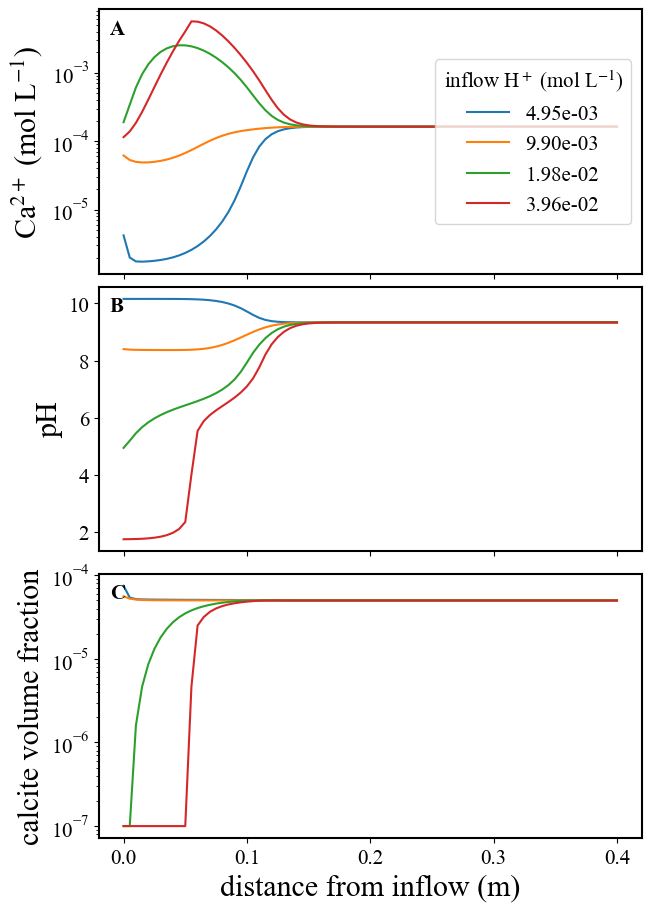

In [4]:
def final_profile(ds, var):
    """Profile of `var` at the final output time, collapsing singleton x, y.

    Returns a DataArray with dims (file_num, z).
    """
    return ds[var].isel(output=-1).squeeze(drop=True)

z = gsc['z'].values

fields = [
    (final_profile(gsc, 'ca+2'),       r'Ca$^{2+}$ (mol L$^{-1}$)', 'log'),
    (final_profile(gsm, 'pH'),         'pH',                        'linear'),
    (final_profile(gsv, 'calcite-ch'), 'calcite volume fraction',   'log'),
]

# figsize sets the multi-panel canvas layout only; per-element sizes
# (fonts, line/marker widths) come from the style sheet.
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6.4, 9), constrained_layout=True)
for ax, (da, ylabel, yscale), letter in zip(axes, fields, 'ABC'):
    for i, h in enumerate(INFLOW_H):
        ax.plot(z, da.isel(file_num=i).values, label=f'{h:.2e}')
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.text(0.02, 0.96, letter, transform=ax.transAxes, fontweight='bold',
            va='top', ha='left')

axes[-1].set_xlabel('distance from inflow (m)')
axes[0].legend(loc='center right', title=r'inflow H$^+$ (mol L$^{-1}$)')
fig.savefig('dissol_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary at the inflow node (t = 6 days)

The transition between buffered and acid-breakthrough behaviour is clear: the two milder waters keep calcite intact and the pH high, while the two aggressive waters exhaust the calcite near the inlet and the pH front breaks through.

In [5]:
rows = []
for i, h in enumerate(INFLOW_H):
    rows.append({
        'inflow H+ (mol/L)':        h,
        'inflow pH':                float(final_profile(gsm, 'pH').isel(file_num=i, z=0)),
        'inflow Ca2+ (mol/L)':      float(final_profile(gsc, 'ca+2').isel(file_num=i, z=0)),
        'min calcite vol. frac.':   float(final_profile(gsv, 'calcite-ch').isel(file_num=i).min()),
    })
pd.DataFrame(rows)

,inflow H+ (mol/L),inflow pH,inflow Ca2+ (mol/L),min calcite vol. frac.
0,0.00495,10.160300,0.000004,5.000085e-05
1,0.00990,8.403190,0.000062,5.000085e-05
2,0.01980,4.946549,0.000190,1.000000e-07
3,0.03960,1.748746,0.000115,1.000000e-07
